In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from itertools import islice

from jax import config
config.update("jax_enable_x64", True)

sys.path.insert(0, os.path.abspath(os.path.join('..')))


from uot.problems.generators import GaussianMixtureBarycenterGenerator
from uot.utils.costs import cost_euclid_squared

import jax
import jax.numpy as jnp
from jax import lax

# Imports for Back-and-Forth barycenter
from collections.abc import Sequence
from typing import Optional
from functools import reduce

import numpy as np
import jax.numpy as jnp

from uot.data.measure import GridMeasure
from uot.utils.central_gradient_nd import _central_gradient_nd

from uot.solvers.back_and_forth.method import backnforth_sqeuclidean_nd

from functools import partial
from typing import Callable, Optional, Tuple, Dict, Any

from uot.utils.central_gradient_nd import _central_gradient_nd
from uot.solvers.back_and_forth.method import backnforth_sqeuclidean_nd
# from .pushforward import adaptive_pushforward_nd
from uot.solvers.back_and_forth.forward_pushforward import cic_pushforward_nd
from uot.solvers.back_and_forth.pushforward import adaptive_pushforward_nd
from uot.solvers.back_and_forth.monge_map import (
    monge_map_from_psi_nd,
    monge_map_cic_from_psi_nd,
    monge_map_adaptive_from_psi_nd,
)


In [2]:
def plot_measure(ax, measure, title, cmap='viridis'):
    if hasattr(measure, 'weights_nd') and hasattr(measure, 'axes'):
        axes = measure.axes
        weights = np.asarray(measure.weights_nd)
        if len(axes) == 1:
            x = np.asarray(axes[0])
            ax.plot(x, weights.reshape(-1))
            ax.set_title(title)
            return
        extent = (
            float(axes[0][0]), float(axes[0][-1]),
            float(axes[1][0]), float(axes[1][-1]),
        )
        ax.imshow(weights.T, extent=extent, origin='lower', cmap=cmap)
        ax.set_title(title)
        ax.set_axis_off()
        return

    points, weights = measure.to_discrete()
    points = np.asarray(points)
    weights = np.asarray(weights)
    if points.ndim == 1:
        points = points.reshape(-1, 1)
    if points.shape[1] == 1:
        ax.plot(points[:, 0], weights)
    else:
        ax.scatter(points[:, 0], points[:, 1], c=weights, s=8, cmap=cmap)
    ax.set_title(title)
    ax.set_axis_off()


In [3]:
# Instantiate the generator (single-component Gaussians by default).

gen = GaussianMixtureBarycenterGenerator(
    name="gmm-bary",
    dim=1,
    num_components=1,
    n_points=15,
    num_datasets=3,
    borders=(0.0, 1.0),
    cost_fn=cost_euclid_squared,
    num_marginals=3,
    use_jax=True,
    seed=42,
    measure_mode="grid",
    cell_discretization="cell-centered",
)

problems = list(islice(gen.generate(), 3))


In [4]:
def _stack_measures(measures_weights):
    """Stack a sequence of measures into a single array.

    Parameters
    ----------
    measures_weights : jnp.ndarray | Sequence[jnp.ndarray]
        Either a pre-stacked array of shape (J, *gridshape) or a sequence of
        arrays each with shape (*gridshape).

    Returns
    -------
    jnp.ndarray
        A stacked array of shape (J, *gridshape).
    """
    if isinstance(measures_weights, jnp.ndarray):
        return measures_weights
    return jnp.stack(list(measures_weights), axis=0)


def _resolve_monge_map_fn(pushforward_fn: Callable) -> Callable:
    if pushforward_fn is adaptive_pushforward_nd:
        return monge_map_adaptive_from_psi_nd
    if pushforward_fn is cic_pushforward_nd:
        return monge_map_cic_from_psi_nd
    return monge_map_from_psi_nd


@partial(
    jax.jit,
    static_argnames=(
        "outer_maxiter",
        "transport_maxiter",
        "pushforward_fn",
        "transport_error_metric",
        "return_monge_maps",
    ),
)
def backnforth_barycenter_sqeuclidean_nd_jax(
    weights: jnp.ndarray,                 # (J,)
    measures: jnp.ndarray,                # (J, *gridshape)
    coordinates: Any,                     # pytree (e.g. tuple/list of coord arrays)
    barycenter_init: Optional[jnp.ndarray] = None,  # (*gridshape,)
    outer_maxiter: int = 15,
    stopping_tol: float = 5e-4,
    relaxation: float = 1.0,
    transport_stepsize: float = 1.0,
    transport_maxiter: int = 500,
    transport_tol: float = 1e-3,
    transport_error_metric: str = "h1_psi_relative",
    pushforward_fn: Optional[Callable] = cic_pushforward_nd,
    return_monge_maps: bool = False,
) -> Tuple[jnp.ndarray, Dict[str, jnp.ndarray]]:
    """Compute a Wasserstein barycenter with a JAX-jitted back-and-forth solver.

    This function runs an outer fixed-point loop to update the barycenter
    ``mu`` and, at each iteration, solves J transport problems in parallel
    (one per input measure) via ``jax.vmap``. The outer loop is implemented
    with ``lax.while_loop`` to be JIT-friendly and uses the PHI potential to
    define the stopping residual while the PSI potential is used for the
    pushforward update (as in the original implementation).

    Parameters
    ----------
    weights : jnp.ndarray
        Barycenter weights of shape (J,). These are normalized internally to
        sum to 1 with numerical safeguards.
    measures : jnp.ndarray
        Stacked input measures of shape (J, *gridshape).
    coordinates : Any
        Coordinate pytree passed to the transport solver
        ``backnforth_sqeuclidean_nd`` (e.g. tuple/list of coordinate arrays).
    barycenter_init : jnp.ndarray | None, optional
        Optional initialization for the barycenter with shape (*gridshape).
        If ``None``, the arithmetic mean of ``measures`` is used.
    outer_maxiter : int, default=15
        Maximum number of outer barycenter iterations.
    stopping_tol : float, default=5e-4
        Threshold on the maximum absolute gradient of the aggregated PHI
        potential used to stop the outer loop.
    relaxation : float, default=1.0
        Relaxation factor in (0, 1] for the barycenter update.
    transport_stepsize : float, default=1.0
        Step size passed to ``backnforth_sqeuclidean_nd``.
    transport_maxiter : int, default=500
        Maximum iterations for each transport solve.
    transport_tol : float, default=1e-3
        Tolerance for each transport solve.
    transport_error_metric : str, default="h1_psi_relative"
        Error metric name forwarded to ``backnforth_sqeuclidean_nd``.
    pushforward_fn : Callable | None, default=cic_pushforward_nd
        Pushforward function used to update the barycenter with the aggregated
        PSI potential. Must accept ``(mu, potential)`` and return a tuple
        ``(pushed_density, aux)``.
    return_monge_maps : bool, default=False
        If True, compute and return the per-measure Monge maps for the final
        barycenter in the diagnostics dictionary (key ``"monge_maps"``).

    Returns
    -------
    Tuple[jnp.ndarray, Dict[str, jnp.ndarray]]
        A tuple ``(mu, diagnostics)`` where:
        - ``mu`` is the final barycenter density, shape (*gridshape)
        - ``diagnostics`` contains:
          - ``iterations``: scalar number of outer iterations
          - ``final_residual``: scalar residual at termination
        - ``residual_hist``: array of shape (outer_maxiter,)
        - ``max_transport_error_hist``: array of shape (outer_maxiter,)
        - ``max_marginal_error_hist``: array of shape (outer_maxiter,)
        - ``monge_maps`` (optional): array of shape (J, *gridshape, d)

    Notes
    -----
    - ``backnforth_sqeuclidean_nd`` must be JAX-traceable and is assumed to
      return a tuple where ``out[1]`` is ``phi``, ``out[2]`` is ``psi``, and
      ``out[4]`` is ``rho_mu``. If the solver output changes, update indices.
    - ``outer_maxiter``, ``transport_maxiter``, ``pushforward_fn``, and
      ``transport_error_metric`` are static arguments in the JIT signature.
    """

    if pushforward_fn is None:
        raise ValueError("pushforward_fn must be provided (e.g. adaptive_pushforward_nd).")

    # normalize weights
    weights = jnp.asarray(weights, dtype=measures.dtype)
    weights = weights / jnp.maximum(weights.sum(), jnp.finfo(weights.dtype).eps)

    # init barycenter
    if barycenter_init is None:
        barycenter_init = measures.mean(axis=0)  # arithmetic mean across J
    mu0 = jnp.clip(barycenter_init, 0.0)
    mu0 = mu0 / jnp.maximum(mu0.sum(), jnp.finfo(mu0.dtype).eps)

    # relaxation in (0,1]
    relaxation = jnp.asarray(relaxation, dtype=mu0.dtype)
    relaxation = jnp.clip(relaxation, jnp.asarray(1e-12, mu0.dtype), jnp.asarray(1.0, mu0.dtype))

    # --- per-pair solve: (mu, nu) -> (phi, psi, rho_mu, l1_err, l2_err)
    def _pair_solve(mu, nu):
        out = backnforth_sqeuclidean_nd(
            mu=mu,
            nu=nu,
            coordinates=coordinates,
            stepsize=transport_stepsize,
            maxiterations=transport_maxiter,
            tolerance=transport_tol,
            progressbar=False,
            pushforward_fn=pushforward_fn,
            error_metric=transport_error_metric,
        )

        # IMPORTANT: adjust indices if your solver returns in different positions
        phi = out[1]     # was "_" in your original destructuring
        psi = out[2]
        rho_mu = out[4]

        l1_err = jnp.sum(jnp.abs(rho_mu - nu))
        l2_err = jnp.sum(jnp.square(rho_mu - nu))
        return phi, psi, rho_mu, l1_err, l2_err

    # vectorize across measures: mu is shared (None), nu varies along axis 0
    vmapped_pair_solve = jax.vmap(
        _pair_solve,
        in_axes=(None, 0),
        out_axes=(0, 0, 0, 0, 0),
    )

    # fixed-size diagnostic buffers (jit-friendly)
    residual_hist = jnp.zeros((outer_maxiter,), dtype=mu0.dtype)
    max_transport_err_hist = jnp.zeros((outer_maxiter,), dtype=mu0.dtype)
    max_marginal_err_hist = jnp.zeros((outer_maxiter,), dtype=mu0.dtype)

    init_residual = jnp.asarray(jnp.inf, dtype=mu0.dtype)
    carry0 = (0, mu0, init_residual, residual_hist, max_transport_err_hist, max_marginal_err_hist)

    def cond_fn(carry):
        i, _, residual, *_ = carry
        return jnp.logical_and(i < outer_maxiter, residual > stopping_tol)

    def body_fn(carry):
        i, mu, _, residual_hist, max_transport_hist, max_marginal_hist = carry

        # parallel transport solves
        phis, psis, rhos_mu, l1_errs, l2_errs = vmapped_pair_solve(mu, measures)

        # broadcast weights to field shape
        # psis has shape (J, *gridshape), so add singleton dims
        w = weights.reshape((weights.shape[0],) + (1,) * (psis.ndim - 1))

        # accumulate both potentials
        phi_accum = jnp.sum(w * phis, axis=0)
        psi_accum = jnp.sum(w * psis, axis=0)

        # residual computed with PHI
        grad_residual = _central_gradient_nd(phi_accum)
        residual = jnp.max(jnp.abs(grad_residual))

        # errors
        max_transport_error = jnp.max(l1_errs)
        max_marginal_error = jnp.max(l2_errs)

        # pushforward uses PSI (unchanged)
        pushed_density, _ = pushforward_fn(mu, -psi_accum)
        mu_new = (1.0 - relaxation) * mu + relaxation * pushed_density
        mu_new = jnp.clip(mu_new, 0.0)
        mu_new = mu_new / jnp.maximum(mu_new.sum(), jnp.finfo(mu_new.dtype).eps)

        # write histories
        residual_hist = residual_hist.at[i].set(residual)
        max_transport_hist = max_transport_hist.at[i].set(max_transport_error)
        max_marginal_hist = max_marginal_hist.at[i].set(max_marginal_error)

        return (i + 1, mu_new, residual, residual_hist, max_transport_hist, max_marginal_hist)

    i_fin, mu_fin, residual_fin, residual_hist, max_transport_hist, max_marginal_hist = lax.while_loop(
        cond_fn, body_fn, carry0
    )

    diagnostics = {
        "iterations": i_fin,                         # scalar int
        "final_residual": residual_fin,              # scalar
        "residual_hist": residual_hist,              # (outer_maxiter,)
        "max_transport_error_hist": max_transport_hist,  # (outer_maxiter,)
        "max_marginal_error_hist": max_marginal_hist,    # (outer_maxiter,)
    }

    if return_monge_maps:
        # Re-solve transports from the final barycenter to get final psi's.
        _, psis_fin, _, _, _ = vmapped_pair_solve(mu_fin, measures)
        monge_map_fn = _resolve_monge_map_fn(pushforward_fn)
        monge_maps = jax.vmap(lambda psi: monge_map_fn(psi=-psi), in_axes=0)(psis_fin)
        monge_maps = jnp.moveaxis(monge_maps, 1, -1)  # (J, *gridshape, d)
        diagnostics["monge_maps"] = monge_maps
    return mu_fin, diagnostics


def backnforth_barycenter_sqeuclidean_nd_optimized(
    weights,
    measures_weights,
    coordinates,
    barycenter_init=None,
    outer_maxiter: int = 15,
    stopping_tol: float = 5e-4,
    relaxation: float = 1.0,
    transport_stepsize: float = 1.0,
    transport_maxiter: int = 500,
    transport_tol: float = 1e-3,
    transport_error_metric: str = "h1_psi_relative",
    pushforward_fn: Optional[Callable] = cic_pushforward_nd,
    return_monge_maps: bool = False,
):
    """Convenience wrapper for the JAX barycenter solver.

    This function mirrors the original API and allows ``measures_weights`` to
    be either a stacked array or a sequence of arrays. It forwards all solver
    parameters to ``backnforth_barycenter_sqeuclidean_nd_jax``.

    Parameters
    ----------
    weights : array-like
        Barycenter weights of shape (J,).
    measures_weights : jnp.ndarray | Sequence[jnp.ndarray]
        Input measures as either a stacked array of shape (J, *gridshape) or
        a sequence of arrays each with shape (*gridshape).
    coordinates : Any
        Coordinate pytree for the transport solver.
    barycenter_init : jnp.ndarray | None, optional
        Optional initialization for the barycenter with shape (*gridshape).
    outer_maxiter : int, default=15
        Maximum number of outer iterations.
    stopping_tol : float, default=5e-4
        Outer loop stopping tolerance.
    relaxation : float, default=1.0
        Relaxation factor in (0, 1] for the barycenter update.
    transport_stepsize : float, default=1.0
        Step size for each transport solve.
    transport_maxiter : int, default=500
        Maximum iterations for each transport solve.
    transport_tol : float, default=1e-3
        Tolerance for each transport solve.
    transport_error_metric : str, default="h1_psi_relative"
        Error metric name forwarded to ``backnforth_sqeuclidean_nd``.
    pushforward_fn : Callable | None, default=cic_pushforward_nd
        Pushforward function used for the barycenter update.
    return_monge_maps : bool, default=False
        If True, include per-measure Monge maps in the diagnostics output.

    Returns
    -------
    Tuple[jnp.ndarray, Dict[str, jnp.ndarray]]
        The final barycenter density and diagnostics dictionary, matching
        ``backnforth_barycenter_sqeuclidean_nd_jax``.
    """
    measures = _stack_measures(measures_weights)
    weights = jnp.asarray(weights, dtype=measures.dtype)

    mu, diag = backnforth_barycenter_sqeuclidean_nd_jax(
        weights=weights,
        measures=measures,
        coordinates=coordinates,
        barycenter_init=barycenter_init,
        outer_maxiter=outer_maxiter,
        stopping_tol=stopping_tol,
        relaxation=relaxation,
        transport_stepsize=transport_stepsize,
        transport_maxiter=transport_maxiter,
        transport_tol=transport_tol,
        transport_error_metric=transport_error_metric,
        pushforward_fn=pushforward_fn,
        return_monge_maps=return_monge_maps,
    )
    return mu, diag


In [5]:
def _stack_measures(measures_weights):
    """Stack a sequence of measures into a single array.

    Parameters
    ----------
    measures_weights : jnp.ndarray | Sequence[jnp.ndarray]
        Either a pre-stacked array of shape (J, *gridshape) or a sequence of
        arrays each with shape (*gridshape).

    Returns
    -------
    jnp.ndarray
        A stacked array of shape (J, *gridshape).
    """
    if isinstance(measures_weights, jnp.ndarray):
        return measures_weights
    return jnp.stack(list(measures_weights), axis=0)


def _resolve_monge_map_fn(pushforward_fn: Callable) -> Callable:
    if pushforward_fn is adaptive_pushforward_nd:
        return monge_map_adaptive_from_psi_nd
    if pushforward_fn is cic_pushforward_nd:
        return monge_map_cic_from_psi_nd
    return monge_map_from_psi_nd


@partial(
    jax.jit,
    static_argnames=(
        "outer_maxiter",
        "transport_maxiter",
        "pushforward_fn",
        "transport_error_metric",
        "return_monge_maps",
    ),
)
def backnforth_regularized_barycenter_sqeuclidean_nd_jax(
    weights: jnp.ndarray,                 # (J,)
    measures: jnp.ndarray,                # (J, *gridshape)
    coordinates: Any,                     # pytree (e.g. tuple/list of coord arrays)
    barycenter_init: Optional[jnp.ndarray] = None,  # (*gridshape,)
    outer_maxiter: int = 15,
    stopping_tol: float = 5e-4,
    tau: float = 1e-2,
    relaxation: float = 1.0,
    transport_stepsize: float = 1.0,
    transport_maxiter: int = 500,
    transport_tol: float = 1e-3,
    transport_error_metric: str = "h1_psi_relative",
    pushforward_fn: Optional[Callable] = cic_pushforward_nd,
    return_monge_maps: bool = False,
) -> Tuple[jnp.ndarray, Dict[str, jnp.ndarray]]:
    """Compute a Wasserstein barycenter with a JAX-jitted back-and-forth solver.

    This function runs an outer fixed-point loop to update the barycenter
    ``mu`` and, at each iteration, solves J transport problems in parallel
    (one per input measure) via ``jax.vmap``. The outer loop is implemented
    with ``lax.while_loop`` to be JIT-friendly and uses the PHI potential to
    define the stopping residual while the PSI potential is used for the
    pushforward update (as in the original implementation).

    Parameters
    ----------
    weights : jnp.ndarray
        Barycenter weights of shape (J,). These are normalized internally to
        sum to 1 with numerical safeguards.
    measures : jnp.ndarray
        Stacked input measures of shape (J, *gridshape).
    coordinates : Any
        Coordinate pytree passed to the transport solver
        ``backnforth_sqeuclidean_nd`` (e.g. tuple/list of coordinate arrays).
    barycenter_init : jnp.ndarray | None, optional
        Optional initialization for the barycenter with shape (*gridshape).
        If ``None``, the arithmetic mean of ``measures`` is used.
    outer_maxiter : int, default=15
        Maximum number of outer barycenter iterations.
    stopping_tol : float, default=5e-4
        Threshold on the maximum absolute gradient of the aggregated PHI
        potential used to stop the outer loop.
    relaxation : float, default=1.0
        Relaxation factor in (0, 1] for the barycenter update.
    transport_stepsize : float, default=1.0
        Step size passed to ``backnforth_sqeuclidean_nd``.
    transport_maxiter : int, default=500
        Maximum iterations for each transport solve.
    transport_tol : float, default=1e-3
        Tolerance for each transport solve.
    transport_error_metric : str, default="h1_psi_relative"
        Error metric name forwarded to ``backnforth_sqeuclidean_nd``.
    pushforward_fn : Callable | None, default=cic_pushforward_nd
        Pushforward function used to update the barycenter with the aggregated
        PSI potential. Must accept ``(mu, potential)`` and return a tuple
        ``(pushed_density, aux)``.
    return_monge_maps : bool, default=False
        If True, compute and return the per-measure Monge maps for the final
        barycenter in the diagnostics dictionary (key ``"monge_maps"``).

    Returns
    -------
    Tuple[jnp.ndarray, Dict[str, jnp.ndarray]]
        A tuple ``(mu, diagnostics)`` where:
        - ``mu`` is the final barycenter density, shape (*gridshape)
        - ``diagnostics`` contains:
          - ``iterations``: scalar number of outer iterations
          - ``final_residual``: scalar residual at termination
        - ``residual_hist``: array of shape (outer_maxiter,)
        - ``max_transport_error_hist``: array of shape (outer_maxiter,)
        - ``max_marginal_error_hist``: array of shape (outer_maxiter,)
        - ``monge_maps`` (optional): array of shape (J, *gridshape, d)

    Notes
    -----
    - ``backnforth_sqeuclidean_nd`` must be JAX-traceable and is assumed to
      return a tuple where ``out[1]`` is ``phi``, ``out[2]`` is ``psi``, and
      ``out[4]`` is ``rho_mu``. If the solver output changes, update indices.
    - ``outer_maxiter``, ``transport_maxiter``, ``pushforward_fn``, and
      ``transport_error_metric`` are static arguments in the JIT signature.
    """

    if pushforward_fn is None:
        raise ValueError("pushforward_fn must be provided (e.g. adaptive_pushforward_nd).")

    # normalize weights
    weights = jnp.asarray(weights, dtype=measures.dtype)
    weights = weights / jnp.maximum(weights.sum(), jnp.finfo(weights.dtype).eps)

    # init barycenter
    if barycenter_init is None:
        barycenter_init = measures.mean(axis=0)  # arithmetic mean across J
    mu0 = jnp.clip(barycenter_init, 0.0)
    mu0 = mu0 / jnp.maximum(mu0.sum(), jnp.finfo(mu0.dtype).eps)

    # relaxation in (0,1]
    relaxation = jnp.asarray(relaxation, dtype=mu0.dtype)
    relaxation = jnp.clip(relaxation, jnp.asarray(1e-12, mu0.dtype), jnp.asarray(1.0, mu0.dtype))

    # --- per-pair solve: (mu, nu) -> (phi, psi, rho_mu, l1_err, l2_err)
    def _pair_solve(mu, nu):
        out = backnforth_sqeuclidean_nd(
            mu=mu,
            nu=nu,
            coordinates=coordinates,
            stepsize=transport_stepsize,
            maxiterations=transport_maxiter,
            tolerance=transport_tol,
            progressbar=False,
            pushforward_fn=pushforward_fn,
            error_metric=transport_error_metric,
        )

        # IMPORTANT: adjust indices if your solver returns in different positions
        phi = out[1]     # was "_" in your original destructuring
        psi = out[2]
        rho_mu = out[4]

        l1_err = jnp.sum(jnp.abs(rho_mu - nu))
        l2_err = jnp.sum(jnp.square(rho_mu - nu))
        return phi, psi, rho_mu, l1_err, l2_err

    # vectorize across measures: mu is shared (None), nu varies along axis 0
    vmapped_pair_solve = jax.vmap(
        _pair_solve,
        in_axes=(None, 0),
        out_axes=(0, 0, 0, 0, 0),
    )

    # fixed-size diagnostic buffers (jit-friendly)
    residual_hist = jnp.zeros((outer_maxiter,), dtype=mu0.dtype)
    max_transport_err_hist = jnp.zeros((outer_maxiter,), dtype=mu0.dtype)
    max_marginal_err_hist = jnp.zeros((outer_maxiter,), dtype=mu0.dtype)

    init_residual = jnp.asarray(jnp.inf, dtype=mu0.dtype)
    carry0 = (0, mu0, init_residual, residual_hist, max_transport_err_hist, max_marginal_err_hist)

    def cond_fn(carry):
        i, _, residual, *_ = carry
        return jnp.logical_and(i < outer_maxiter, residual > stopping_tol)

    def body_fn(carry):
        i, mu, _, residual_hist, max_transport_hist, max_marginal_hist = carry

        # parallel transport solves
        phis, psis, rhos_mu, l1_errs, l2_errs = vmapped_pair_solve(mu, measures)

        # broadcast weights to field shape
        # psis has shape (J, *gridshape), so add singleton dims
        w = weights.reshape((weights.shape[0],) + (1,) * (psis.ndim - 1))

        # accumulate both potentials
        phi_accum = jnp.sum(w * phis, axis=0)
        psi_accum = jnp.sum(w * psis, axis=0)

        # residual computed with PHI
        grad_residual = _central_gradient_nd(phi_accum)
        residual = jnp.max(jnp.abs(grad_residual))

        # errors
        max_transport_error = jnp.max(l1_errs)
        max_marginal_error = jnp.max(l2_errs)

        # pushforward uses PSI (unchanged)
        # pushed_density, _ = pushforward_fn(mu, psi_accum)
        # in_exp = -(1/tau) * (phi_accum)
        # in_exp = in_exp - in_exp.max()
        # pushed_density = jnp.exp(in_exp)
        # pushed_density = jnp.exp(-(1/tau) * -psi_accum)
        pushed_density = jnp.exp(-(1/tau) * -phi_accum)
        pushed_density /= pushed_density.sum()
        mu_new = (1.0 - relaxation) * mu + relaxation * pushed_density
        mu_new = jnp.clip(mu_new, 0.0)
        mu_new = mu_new / jnp.maximum(mu_new.sum(), jnp.finfo(mu_new.dtype).eps)

        # write histories
        residual_hist = residual_hist.at[i].set(residual)
        max_transport_hist = max_transport_hist.at[i].set(max_transport_error)
        max_marginal_hist = max_marginal_hist.at[i].set(max_marginal_error)

        return (i + 1, mu_new, residual, residual_hist, max_transport_hist, max_marginal_hist)

    i_fin, mu_fin, residual_fin, residual_hist, max_transport_hist, max_marginal_hist = lax.while_loop(
        cond_fn, body_fn, carry0
    )

    diagnostics = {
        "iterations": i_fin,                         # scalar int
        "final_residual": residual_fin,              # scalar
        "residual_hist": residual_hist,              # (outer_maxiter,)
        "max_transport_error_hist": max_transport_hist,  # (outer_maxiter,)
        "max_marginal_error_hist": max_marginal_hist,    # (outer_maxiter,)
    }

    if return_monge_maps:
        # Re-solve transports from the final barycenter to get final psi's.
        _, psis_fin, _, _, _ = vmapped_pair_solve(mu_fin, measures)
        monge_map_fn = _resolve_monge_map_fn(pushforward_fn)
        monge_maps = jax.vmap(lambda psi: monge_map_fn(psi=-psi), in_axes=0)(psis_fin)
        monge_maps = jnp.moveaxis(monge_maps, 1, -1)  # (J, *gridshape, d)
        diagnostics["monge_maps"] = monge_maps
    return mu_fin, diagnostics


def backnforth_regularized_barycenter_sqeuclidean_nd_optimized(
    weights,
    measures_weights,
    coordinates,
    barycenter_init=None,
    outer_maxiter: int = 15,
    stopping_tol: float = 5e-4,
    relaxation: float = 1.0,
    tau: float = 1e-2,
    transport_stepsize: float = 1.0,
    transport_maxiter: int = 500,
    transport_tol: float = 1e-3,
    transport_error_metric: str = "h1_psi_relative",
    pushforward_fn: Optional[Callable] = cic_pushforward_nd,
    return_monge_maps: bool = False,
):
    """Convenience wrapper for the JAX barycenter solver.

    This function mirrors the original API and allows ``measures_weights`` to
    be either a stacked array or a sequence of arrays. It forwards all solver
    parameters to ``backnforth_barycenter_sqeuclidean_nd_jax``.

    Parameters
    ----------
    weights : array-like
        Barycenter weights of shape (J,).
    measures_weights : jnp.ndarray | Sequence[jnp.ndarray]
        Input measures as either a stacked array of shape (J, *gridshape) or
        a sequence of arrays each with shape (*gridshape).
    coordinates : Any
        Coordinate pytree for the transport solver.
    barycenter_init : jnp.ndarray | None, optional
        Optional initialization for the barycenter with shape (*gridshape).
    outer_maxiter : int, default=15
        Maximum number of outer iterations.
    stopping_tol : float, default=5e-4
        Outer loop stopping tolerance.
    relaxation : float, default=1.0
        Relaxation factor in (0, 1] for the barycenter update.
    transport_stepsize : float, default=1.0
        Step size for each transport solve.
    transport_maxiter : int, default=500
        Maximum iterations for each transport solve.
    transport_tol : float, default=1e-3
        Tolerance for each transport solve.
    transport_error_metric : str, default="h1_psi_relative"
        Error metric name forwarded to ``backnforth_sqeuclidean_nd``.
    pushforward_fn : Callable | None, default=cic_pushforward_nd
        Pushforward function used for the barycenter update.
    return_monge_maps : bool, default=False
        If True, include per-measure Monge maps in the diagnostics output.

    Returns
    -------
    Tuple[jnp.ndarray, Dict[str, jnp.ndarray]]
        The final barycenter density and diagnostics dictionary, matching
        ``backnforth_barycenter_sqeuclidean_nd_jax``.
    """
    measures = _stack_measures(measures_weights)
    weights = jnp.asarray(weights, dtype=measures.dtype)

    mu, diag = backnforth_regularized_barycenter_sqeuclidean_nd_jax(
        weights=weights,
        measures=measures,
        coordinates=coordinates,
        barycenter_init=barycenter_init,
        outer_maxiter=outer_maxiter,
        stopping_tol=stopping_tol,
        relaxation=relaxation,
        tau=tau,
        transport_stepsize=transport_stepsize,
        transport_maxiter=transport_maxiter,
        transport_tol=transport_tol,
        transport_error_metric=transport_error_metric,
        pushforward_fn=pushforward_fn,
        return_monge_maps=return_monge_maps,
    )
    return mu, diag


Back-and-Forth finished in 15 iterations
Back-and-Forth (with regularization) finished in 30 iterations
grid_axes=[Array([0.03333333, 0.1       , 0.16666667, 0.23333333, 0.3       ,
       0.36666667, 0.43333333, 0.5       , 0.56666667, 0.63333333,
       0.7       , 0.76666667, 0.83333333, 0.9       , 0.96666667],      dtype=float64)]


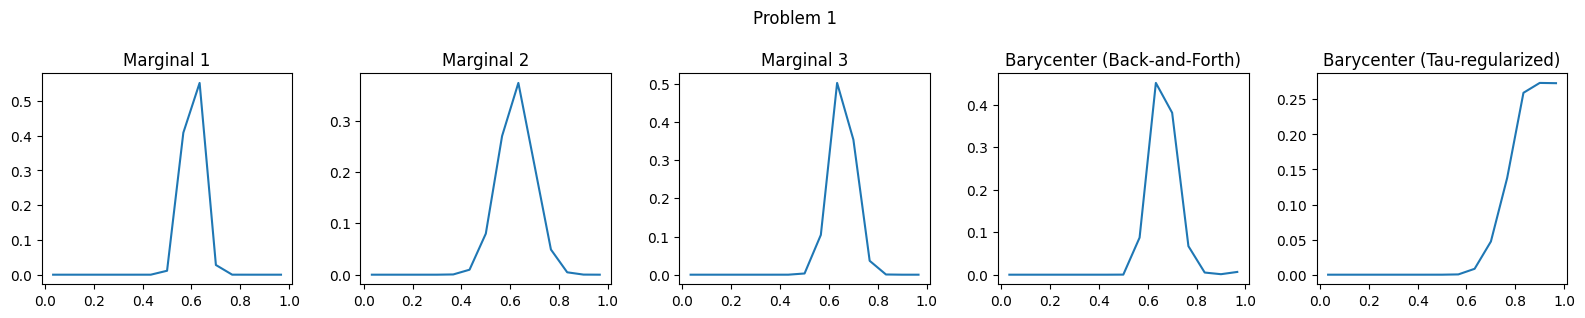

In [6]:
def _stack_grid_measures(measures):
    weights = []
    for measure in measures:
        if hasattr(measure, 'weights_nd'):
            weights.append(jnp.asarray(measure.weights_nd))
        else:
            raise ValueError("Expected GridMeasure with weights_nd for plotting/solver inputs.")
    return jnp.stack(weights, axis=0)


def _plot_density(ax, density, grid_axes, title, cmap='viridis'):
    if len(grid_axes) == 1:
        x = np.asarray(grid_axes[0])
        y = np.asarray(density).reshape(-1)
        ax.plot(x, y)
        ax.set_title(title)
        return
    if len(grid_axes) == 2:
        extent = (
            float(grid_axes[0][0]), float(grid_axes[0][-1]),
            float(grid_axes[1][0]), float(grid_axes[1][-1]),
        )
        ax.imshow(np.asarray(density).T, extent=extent, origin='lower', cmap=cmap)
        ax.set_title(title)
        ax.set_axis_off()
        return
    raise ValueError(f"Unsupported grid dimension: {len(grid_axes)}")



problem = problems[0]
measures = problem.get_marginals()
grid_axes = measures[0].axes
stacked = _stack_grid_measures(measures)
lambdas = jnp.asarray(problem.lambdas())

mu_bf, diag_bf = backnforth_barycenter_sqeuclidean_nd_optimized(
    weights=lambdas,
    measures_weights=stacked,
    coordinates=grid_axes,
    outer_maxiter=15,
    stopping_tol=5e-4,
    transport_maxiter=500,
    transport_tol=1e-3,
    pushforward_fn=cic_pushforward_nd,
)
print(f"Back-and-Forth finished in {diag_bf['iterations']} iterations")

mu_reg, diag_reg = backnforth_regularized_barycenter_sqeuclidean_nd_optimized(
    weights=lambdas,
    measures_weights=stacked,
    coordinates=grid_axes,
    outer_maxiter=30,
    stopping_tol=5e-4,
    tau=1e-2,
    transport_maxiter=500,
    transport_tol=1e-3,
    pushforward_fn=cic_pushforward_nd,
)
print(f"Back-and-Forth (with regularization) finished in {diag_reg['iterations']} iterations")


mu_bf = mu_bf / jnp.maximum(mu_bf.sum(), 1e-12)
mu_reg = mu_reg / jnp.maximum(mu_reg.sum(), 1e-12)

num_measures = len(measures)
fig, axes_arr = plt.subplots(1, num_measures + 2, figsize=(3.2 * (num_measures + 2), 3.2))
if num_measures + 2 == 1:
    axes_arr = [axes_arr]

for j, measure in enumerate(measures, start=1):
    plot_measure(axes_arr[j - 1], measure, f"Marginal {j}")

print(f"{grid_axes=}")
# plot_measure(axes_arr[num_measures], mu_bf, "barycenter back-and-forth")
_plot_density(axes_arr[num_measures], mu_bf, grid_axes, "Barycenter (Back-and-Forth)")
_plot_density(axes_arr[num_measures + 1], mu_reg, grid_axes, "Barycenter (Tau-regularized)")

fig.suptitle("Problem 1")
plt.tight_layout()
plt.show()


Back-and-Forth finished in 15 iterations
Back-and-Forth (with regularization) finished in 5 iterations


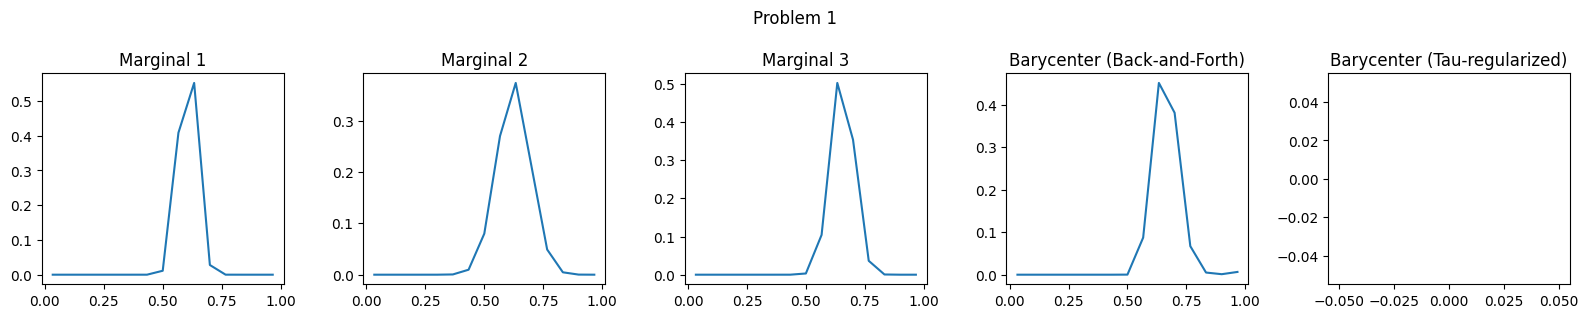

In [7]:
def _stack_grid_measures(measures):
    weights = []
    for measure in measures:
        if hasattr(measure, 'weights_nd'):
            weights.append(jnp.asarray(measure.weights_nd))
        else:
            raise ValueError("Expected GridMeasure with weights_nd for plotting/solver inputs.")
    return jnp.stack(weights, axis=0)


def _plot_density(ax, density, grid_axes, title, cmap='viridis'):
    if len(grid_axes) == 1:
        x = np.asarray(grid_axes[0])
        y = np.asarray(density).reshape(-1)
        ax.plot(x, y)
        ax.set_title(title)
        return
    if len(grid_axes) == 2:
        extent = (
            float(grid_axes[0][0]), float(grid_axes[0][-1]),
            float(grid_axes[1][0]), float(grid_axes[1][-1]),
        )
        ax.imshow(np.asarray(density).T, extent=extent, origin='lower', cmap=cmap)
        ax.set_title(title)
        ax.set_axis_off()
        return
    raise ValueError(f"Unsupported grid dimension: {len(grid_axes)}")


problem = problems[0]
measures = problem.get_marginals()
grid_axes = measures[0].axes
stacked = _stack_grid_measures(measures)
lambdas = jnp.asarray(problem.lambdas())

mu_bf, diag_bf = backnforth_barycenter_sqeuclidean_nd_optimized(
    weights=lambdas,
    measures_weights=stacked,
    coordinates=grid_axes,
    outer_maxiter=15,
    stopping_tol=5e-4,
    transport_maxiter=500,
    transport_tol=1e-3,
    pushforward_fn=cic_pushforward_nd,
)
print(f"Back-and-Forth finished in {diag_bf['iterations']} iterations")

mu_reg, diag_reg = backnforth_regularized_barycenter_sqeuclidean_nd_optimized(
    weights=lambdas,
    measures_weights=stacked,
    coordinates=grid_axes,
    outer_maxiter=30,
    stopping_tol=5e-4,
    tau=1e-4,
    transport_maxiter=500,
    transport_tol=1e-4,
    pushforward_fn=cic_pushforward_nd,
)
print(f"Back-and-Forth (with regularization) finished in {diag_reg['iterations']} iterations")


mu_bf = mu_bf / jnp.maximum(mu_bf.sum(), 1e-12)
mu_reg = mu_reg / jnp.maximum(mu_reg.sum(), 1e-12)

num_measures = len(measures)
fig, axes_arr = plt.subplots(1, num_measures + 2, figsize=(3.2 * (num_measures + 2), 3.2))
if num_measures + 2 == 1:
    axes_arr = [axes_arr]

for j, measure in enumerate(measures, start=1):
    plot_measure(axes_arr[j - 1], measure, f"Marginal {j}")

_plot_density(axes_arr[num_measures], mu_bf, grid_axes, "Barycenter (Back-and-Forth)")
_plot_density(axes_arr[num_measures + 1], mu_reg, grid_axes, "Barycenter (Tau-regularized)")

fig.suptitle("Problem 1")
plt.tight_layout()
plt.show()
